In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import sqrt

In [2]:
data = pd.DataFrame({
    'userId': [1,1,1,2,2,3,3,4,4],
    'movieId': [1,2,3,1,3,2,3,1,2],
    'rating': [5,4,1,4,2,5,4,3,2]
})

print("Dataset:\n", data)


Dataset:
    userId  movieId  rating
0       1        1       5
1       1        2       4
2       1        3       1
3       2        1       4
4       2        3       2
5       3        2       5
6       3        3       4
7       4        1       3
8       4        2       2


In [3]:
user_item_matrix = data.pivot(index='userId', columns='movieId', values='rating').fillna(0)
print("\nUser-Item Matrix:\n", user_item_matrix)


User-Item Matrix:
 movieId    1    2    3
userId                
1        5.0  4.0  1.0
2        4.0  0.0  2.0
3        0.0  5.0  4.0
4        3.0  2.0  0.0


In [4]:
U, sigma, Vt = np.linalg.svd(user_item_matrix, full_matrices=False)

sigma = np.diag(sigma)

predicted_ratings = np.dot(np.dot(U, sigma), Vt)
pred_df = pd.DataFrame(predicted_ratings, columns=user_item_matrix.columns, index=user_item_matrix.index)

print("\nPredicted Ratings:\n", pred_df)


Predicted Ratings:
 movieId             1             2             3
userId                                           
1        5.000000e+00  4.000000e+00  1.000000e+00
2        4.000000e+00  4.798767e-16  2.000000e+00
3       -4.703823e-16  5.000000e+00  4.000000e+00
4        3.000000e+00  2.000000e+00  4.694715e-16


In [5]:
def recommend_movies(user_id, num_recommendations=2):
    user_ratings = user_item_matrix.loc[user_id]
    predictions = pred_df.loc[user_id]

    unseen_movies = user_ratings[user_ratings == 0].index

    recommendations = predictions[unseen_movies].sort_values(ascending=False)
    return recommendations.head(num_recommendations)

print("\nRecommendations for User 1:")
print(recommend_movies(1))


Recommendations for User 1:
Series([], Name: 1, dtype: float64)


In [6]:
actual = user_item_matrix.values.flatten()
predicted = pred_df.values.flatten()

rmse = sqrt(mean_squared_error(actual, predicted))
print("\nRMSE:", rmse)


RMSE: 1.9554099173502205e-15


In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, random_state=42)

train_matrix = train.pivot(index='userId', columns='movieId', values='rating').fillna(0)
test_matrix = test.pivot(index='userId', columns='movieId', values='rating').fillna(0)

U, sigma, Vt = np.linalg.svd(train_matrix, full_matrices=False)
sigma = np.diag(sigma)
pred_train = np.dot(np.dot(U, sigma), Vt)

pred_train_df = pd.DataFrame(pred_train, index=train_matrix.index, columns=train_matrix.columns)

test_matrix = test_matrix.reindex_like(pred_train_df).fillna(0)

rmse_test = sqrt(mean_squared_error(test_matrix.values.flatten(), pred_train_df.values.flatten()))
print("Test RMSE:", rmse_test)

Test RMSE: 3.1091263510296043


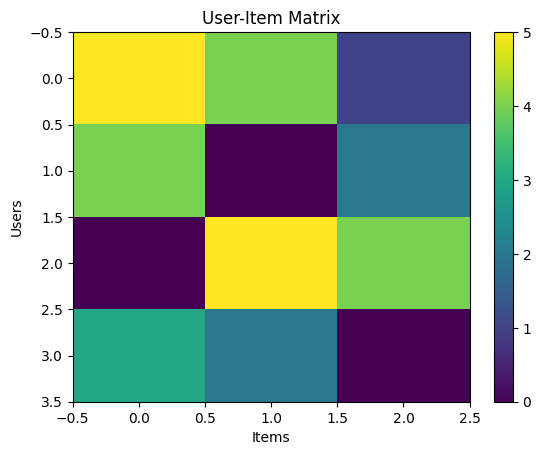

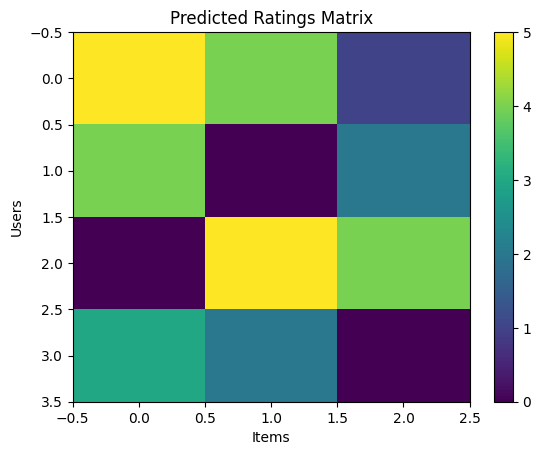

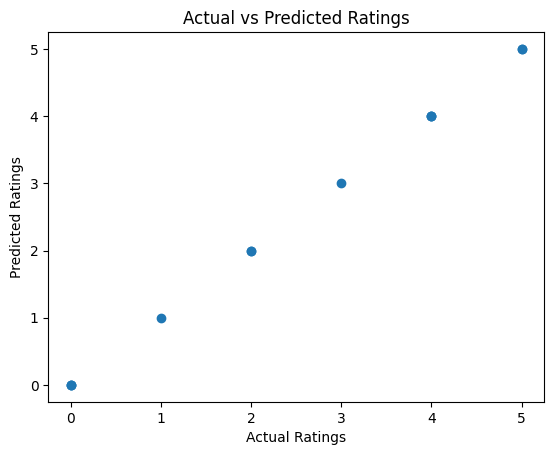

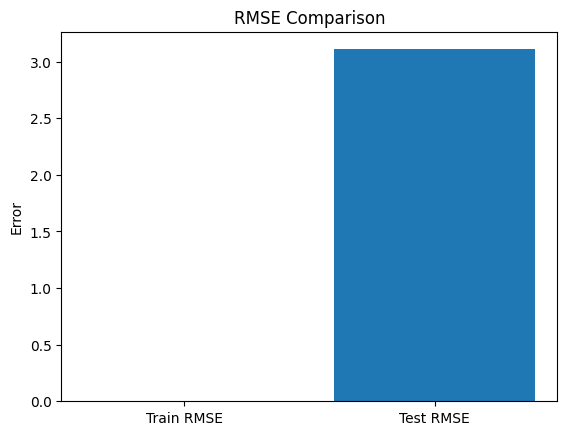

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(user_item_matrix, aspect='auto')
plt.title("User-Item Matrix")
plt.xlabel("Items")
plt.ylabel("Users")
plt.colorbar()

plt.figure()
plt.imshow(pred_df, aspect='auto')
plt.title("Predicted Ratings Matrix")
plt.xlabel("Items")
plt.ylabel("Users")
plt.colorbar()
plt.show()

plt.figure()
plt.scatter(actual, predicted)
plt.title("Actual vs Predicted Ratings")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.show()

plt.figure()
plt.bar(["Train RMSE", "Test RMSE"], [rmse, rmse_test])
plt.title("RMSE Comparison")
plt.ylabel("Error")
plt.show()
